In [1]:
# Nuevo notebook
# Escribe tu código aquí

In [2]:
pip install numpy pandas matplotlib scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


error: externally-managed-environment

× This environment is externally managed
╰─> This Python installation is managed by uv and should not be modified.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


Primeras filas del dataset:
         x1        x2  etiqueta
0 -0.008864  0.113353         0
1  0.242456 -0.075897         0
2 -0.014196 -0.070382         0
3 -0.165579 -0.143002         0
4  0.202125  0.327485         0

Total de muestras: 200

Muestras de entrenamiento: 160
Muestras de prueba: 40

Cargando modelo previamente entrenado desde: mlp_celulas_model.joblib

Accuracy en entrenamiento: 1.0000
Accuracy en prueba: 1.0000

Matriz de confusión (test):
[[20  0]
 [ 0 20]]

Reporte de clasificación (test):
              precision    recall  f1-score   support

 Maligna (0)       1.00      1.00      1.00        20
 Benigna (1)       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



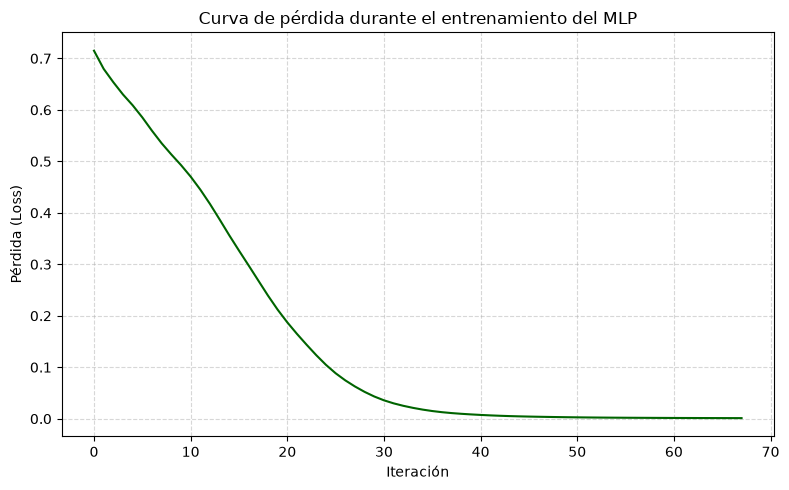

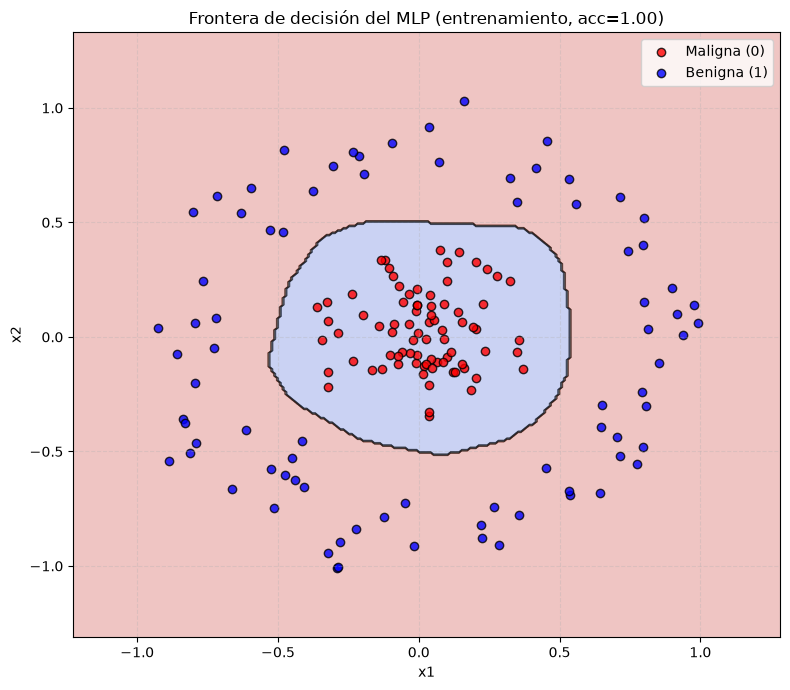

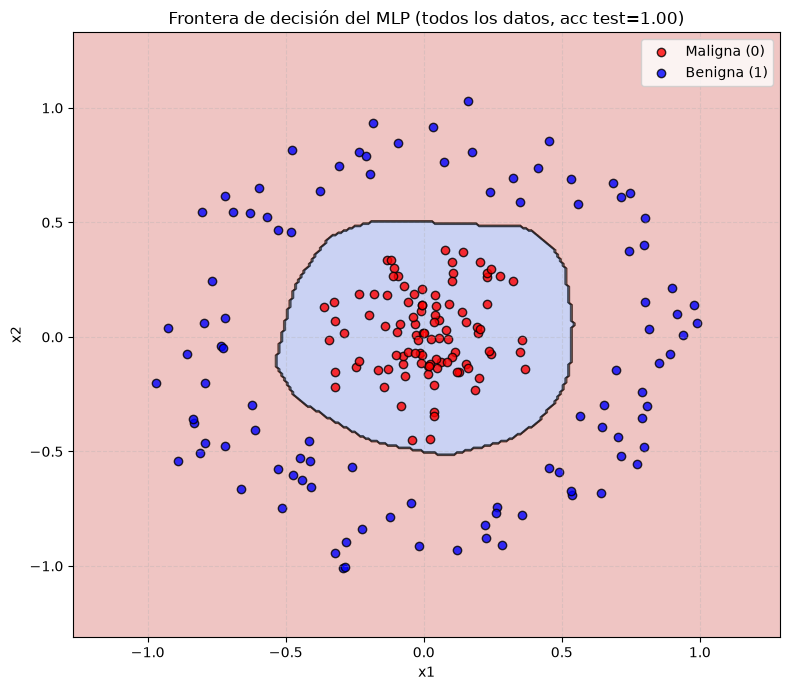


Gráficos guardados: loss_curve.png, decision_boundary_train.png, decision_boundary_full.png


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import os

# ============================================================
# 1. GENERACIÓN DE DATOS (igual que el código original)
# ============================================================
np.random.seed(42)
n_samples_per_class = 100
n_total = n_samples_per_class * 2

theta_0 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_0 = np.random.uniform(0, 0.4, n_samples_per_class)
x1_0 = r_0 * np.cos(theta_0)
x2_0 = r_0 * np.sin(theta_0)
y_0 = np.zeros(n_samples_per_class)

theta_1 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_1 = np.random.uniform(0.7, 1.0, n_samples_per_class)
x1_1 = r_1 * np.cos(theta_1)
x2_1 = r_1 * np.sin(theta_1)
y_1 = np.ones(n_samples_per_class)

x1 = np.concatenate([x1_0, x1_1])
x2 = np.concatenate([x2_0, x2_1])
etiqueta = np.concatenate([y_0, y_1])

ruido = np.random.normal(0, 0.08, n_total)
x2 = x2 + ruido

df_celulas = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'etiqueta': etiqueta.astype(int)
})

print("Primeras filas del dataset:")
print(df_celulas.head())
print(f"\nTotal de muestras: {len(df_celulas)}")

# ============================================================
# 2. PREPARAR DATOS PARA EL MLP
# ============================================================
X = df_celulas[['x1', 'x2']].values
y = df_celulas['etiqueta'].values

# División train/test (80/20), estratificada para mantener el balance de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nMuestras de entrenamiento: {len(X_train)}")
print(f"Muestras de prueba: {len(X_test)}")

# ============================================================
# 3. DEFINIR Y ENTRENAR EL MULTILAYER PERCEPTRON (3 capas ocultas)
# ============================================================
# Nota: este problema NO es linealmente separable (círculos concéntricos),
# por eso necesitamos al menos una capa oculta con activación no lineal.
MODEL_PATH = 'mlp_celulas_model.joblib'

if os.path.exists(MODEL_PATH):
    # Si ya existe un modelo entrenado guardado en disco, lo cargamos
    # en lugar de volver a entrenar desde cero (persistencia).
    print(f"\nCargando modelo previamente entrenado desde: {MODEL_PATH}")
    mlp = joblib.load(MODEL_PATH)
else:
    print("\nNo se encontró un modelo guardado. Entrenando uno nuevo...")
    mlp = MLPClassifier(
        hidden_layer_sizes=(32, 16, 8),   # TRES capas ocultas
        activation='relu',
        solver='adam',
        alpha=1e-4,                        # regularización L2
        learning_rate_init=0.01,
        max_iter=2000,
        random_state=42
    )
    mlp.fit(X_train, y_train)

    # Guardar el modelo entrenado en disco para reutilizarlo después
    joblib.dump(mlp, MODEL_PATH)
    print(f"Modelo entrenado y guardado en: {MODEL_PATH}")

# ============================================================
# 4. EVALUAR EL MODELO
# ============================================================
y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"\nAccuracy en entrenamiento: {acc_train:.4f}")
print(f"Accuracy en prueba: {acc_test:.4f}")
print(f"\nMatriz de confusión (test):\n{confusion_matrix(y_test, y_pred_test)}")
print(f"\nReporte de clasificación (test):\n{classification_report(y_test, y_pred_test, target_names=['Maligna (0)', 'Benigna (1)'])}")

# ============================================================
# 5. VISUALIZAR CURVA DE PÉRDIDA
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, color='darkgreen')
plt.title('Curva de pérdida durante el entrenamiento del MLP')
plt.xlabel('Iteración')
plt.ylabel('Pérdida (Loss)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

# ============================================================
# 6. VISUALIZAR FRONTERA DE DECISIÓN
# ============================================================
def plot_decision_boundary(model, X, y, title, filename):
    h = 0.01
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 7))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.contour(xx, yy, Z, colors='k', linewidths=0.5, alpha=0.5)

    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1],
                color='red', label='Maligna (0)', alpha=0.8, edgecolors='k')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
                color='blue', label='Benigna (1)', alpha=0.8, edgecolors='k')

    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

plot_decision_boundary(mlp, X_train, y_train,
                        f'Frontera de decisión del MLP (entrenamiento, acc={acc_train:.2f})',
                        'decision_boundary_train.png')

plot_decision_boundary(mlp, X, y,
                        f'Frontera de decisión del MLP (todos los datos, acc test={acc_test:.2f})',
                        'decision_boundary_full.png')

print("\nGráficos guardados: loss_curve.png, decision_boundary_train.png, decision_boundary_full.png")

In [7]:
# ============================================================
# 7. OBTENER PROBABILIDADES ESTIMADAS (Maligna y Benigna)
# ============================================================
print("=" * 70)
print("PROBABILIDADES ESTIMADAS PARA CADA MUESTRA DE PRUEBA")
print("=" * 70)

# Obtener probabilidades para el conjunto de prueba
y_pred_proba = mlp.predict_proba(X_test)

# Crear un DataFrame con resultados detallados
resultados_proba = pd.DataFrame({
    'Muestra': range(1, len(X_test) + 1),
    'x1': X_test[:, 0],
    'x2': X_test[:, 1],
    'Prob_Maligna (0)': y_pred_proba[:, 0],
    'Prob_Benigna (1)': y_pred_proba[:, 1],
    'Etiqueta_Real': y_test,
    'Predicción': mlp.predict(X_test)
})

print("\nPrimeras 10 muestras con probabilidades:")
print(resultados_proba.head(10).to_string(index=False))

print("\n\nResumen estadístico de probabilidades:")
print(f"Probabilidad promedio de Maligna (0): {y_pred_proba[:, 0].mean()*100:.2f}%")
print(f"Probabilidad promedio de Benigna (1): {y_pred_proba[:, 1].mean()*100:.2f}%")

print("\n\nTodas las probabilidades estimadas (EN PORCENTAJE):")
print("-" * 70)
for idx, (prob_maligna, prob_benigna) in enumerate(y_pred_proba, 1):
    prediccion = "Benigna" if mlp.predict([X_test[idx-1]])[0] == 1 else "Maligna"
    print(f"Muestra {idx:2d}: Maligna={prob_maligna*100:6.2f}% | Benigna={prob_benigna*100:6.2f}% | Predicción: {prediccion}")

# Guardar resultados en archivo CSV
resultados_proba.to_csv('predicciones_probabilidades.csv', index=False)
print("\n✓ Resultados guardados en: predicciones_probabilidades.csv")

PROBABILIDADES ESTIMADAS PARA CADA MUESTRA DE PRUEBA

Primeras 10 muestras con probabilidades:
 Muestra        x1        x2  Prob_Maligna (0)  Prob_Benigna (1)  Etiqueta_Real  Predicción
       1  0.229895  0.279973          0.999164          0.000836              0           0
       2  0.788867 -0.352129          0.000108          0.999892              1           1
       3 -0.969679 -0.202886          0.000001          0.999999              1           1
       4  0.119971 -0.928342          0.000002          0.999998              1           1
       5 -0.029393  0.007059          0.999904          0.000096              0           0
       6 -0.720146 -0.474688          0.000018          0.999982              1           1
       7  0.195659  0.018228          0.999784          0.000216              0           0
       8  0.566689 -0.346924          0.043063          0.956937              1           1
       9  0.891243 -0.075692          0.000020          0.999980             